# Experimento de robustez para MFW

En este notebook se presenta un experimento para estimar el menor valor de `TOP_N_MFW`, es decir, de características de palabras funcionales, manteniendo el rendimiento de los modelos.

De nuevo, vamos a entrenar una serie de modelos de clasificación multiclase, como ya hicimos en el notebook de `03_machine_learning_methods.ipynb`, pero esta vez vamos a variar el número de características de palabras funcionales que se incluyen en el modelo así como las semillas de entrenamiento.

Esto nos dará una idea de cómo el número de características de palabras funcionales afecta el rendimiento del modelo y nos permitirá identificar un valor óptimo para `TOP_N_MFW` que mantenga un buen rendimiento sin incluir demasiadas características.

In [1]:
from pathlib import Path
from tqdm.auto import tqdm
from joblib import dump

import json
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

from whodunit_stylometry.constants import AUTHORS_NORM_MAP
from whodunit_stylometry.utils.plot_utils import plot_mfw_performance_robustness
from whodunit_stylometry.utils.train_utils import (
    run_experiment,
    build_models_with_seed,
    build_train_test_mfw,
    summarize_result_row,
)

## Configuración


In [2]:
# Fijamos un seed para la división de los datos,
# para que sea consistente a lo largo del barrido
SEED_TO_SPLIT = 42
CORPUS_PATH = Path("../corpus")
ML_ARTIFACTS_PATH = Path("../artifacts/best_mfw_model")
ML_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

# Configuración del barrido
SEEDS_TO_TEST = [0, 1, 2, 3, 4, 5, 10, 20, 42, 123, 150]
TOP_N_MFW_VALUES = [5, 10, 15, 25, 30, 40, 50, 75, 100, 125, 150]

# Criterio para decidir el menor TOP_N_MFW aceptable
PERFORMANCE_METRIC = "test_f1_macro"
TOLERANCE_FROM_BEST = 0.01

## Carga de datos

In [3]:
# Cargamos los metadatos del corpus para tener
# acceso a los textos y autores
df = pd.read_csv(CORPUS_PATH / "corpus_metadata.csv", sep=";")
print(df.shape)
df.head()

(95, 12)


,file_name,author,title,year,type,detective,genre,language,country,source,license,url
0,acd-a_study_in_scarlet.txt,Arthur Conan Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/244/pg244...
1,acd-tales_of_terror_and_mystery.txt,Arthur Conan Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/537/pg537...
2,acd-the_adventures_of_sherlock_holmes.txt,Arthur Conan Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/1661/pg16...
3,acd-the_case_book_of_sherlock_holmes.txt,Arthur Conan Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/69700/pg6...
4,acd-the_hound_of_the_baskervilles.txt,Arthur Conan Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/2852/pg28...


In [4]:
# Normalizamos los nombres de los autores y los
# nombres de los archivos para facilitar su manejo
df["file_name"] = df["file_name"].str[:-4]
df["author_norm"] = df["author"].apply(lambda x: AUTHORS_NORM_MAP.get(x, x))
df["author_norm"].unique()

<ArrowStringArray>
[      'arthur_conan_doyle',     'anna_katharine_green',
          'arthur_morrison', 'gilbert_keith_chesterton',
   'richard_austin_freeman',           'wilkie_collins']
Length: 6, dtype: str

In [5]:
# Añadimos una columna con la ruta a los tokens de cada texto
# ya preparados (ver scripts/corpus_tokenization.py)
df["tokens_path"] = df.apply(
    lambda x: CORPUS_PATH / "tokenized/alpha/lower" / x["author_norm"] / f"{x['file_name']}.json", axis=1
)

## Obtener conjuntos de entrenamiento y test

Del mismo modo que hicimos en el notebook `03_machine_learning_methods.ipynb`, nos vamos a quedar con dos textos de cada autor para el conjunto de test, y el resto para el conjunto de entrenamiento. De estos dos textos, uno será del género de misterio y el otro de otro género, para ver si el modelo es capaz de generalizar sin importar el género.

In [6]:
test_rows = []

for author, g_author in df.groupby("author_norm"):
    mystery_pool = g_author[g_author["genre"] == "mystery"]
    non_mystery_pool = g_author[g_author["genre"] != "mystery"]

    mystery_pick = mystery_pool.sample(n=1, random_state=SEED_TO_SPLIT)
    non_mystery_pick = non_mystery_pool.sample(n=1, random_state=SEED_TO_SPLIT)

    test_rows.append(mystery_pick)
    test_rows.append(non_mystery_pick)

test_df = pd.concat(test_rows, axis=0)
test_df

,file_name,author,title,year,type,detective,genre,language,country,source,license,url,author_norm,tokens_path
43,akg-three_thousand_dollars,Anna Katharine Green,Three Thousand Dollars,1910,novel,NaN,mystery,en,USA,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/32795/pg3...,anna_katharine_green,../corpus/tokenized/alpha/lower/anna_katharine...
44,akg-to_the_minute,Anna Katharine Green,To the Minute,1916,novel,NaN,fiction,en,USA,Project Gutemberg AU,Public domain in the USA.,https://gutenberg.net.au/ebooks17/1701091h.html,anna_katharine_green,../corpus/tokenized/alpha/lower/anna_katharine...
2,acd-the_adventures_of_sherlock_holmes,Arthur Conan Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/1661/pg16...,arthur_conan_doyle,../corpus/tokenized/alpha/lower/arthur_conan_d...
5,acd-the_lost_world,Arthur Conan Doyle,The Lost World,1912,novel,NaN,scifi,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/139/pg139...,arthur_conan_doyle,../corpus/tokenized/alpha/lower/arthur_conan_d...
47,am-chronicles_of_martin_hewitt,Arthur Morrison,Chronicles of Martin Hewitt,1895,short stories,Martin Hewit,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/37820/pg3...,arthur_morrison,../corpus/tokenized/alpha/lower/arthur_morriso...
51,am-the_hole_in_the_wall,Arthur Morrison,The Hole in the Wall,1902,novel,NaN,fiction,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/34538/pg3...,arthur_morrison,../corpus/tokenized/alpha/lower/arthur_morriso...
52,gkc-four_faultless_felons,Gilbert Keith Chesterton,Four Faultless Felons,1930,short stories,NaN,mystery,en,UK,Project Gutemberg AU,Public domain in the USA.,https://gutenberg.net.au/ebooks03/0300781.txt,gilbert_keith_chesterton,../corpus/tokenized/alpha/lower/gilbert_keith_...
64,gkc-the_return_of_don_quixote,Gilbert Keith Chesterton,The Return of Don Quixote,1927,novel,NaN,fiction,en,UK,Project Gutemberg AU,Public domain in the USA.,https://gutenberg.net.au/ebooks09/0900401.txt,gilbert_keith_chesterton,../corpus/tokenized/alpha/lower/gilbert_keith_...
83,raf-the_shadow_of_the_wolf,Richard Austin Freeman,The shadow of the Wolf,1925,novel,Dr. Thorndyke,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/75244/pg7...,richard_austin_freeman,../corpus/tokenized/alpha/lower/richard_austin...
78,raf-the_golden_pool,Richard Austin Freeman,The golden pool,1905,novel,NaN,fiction,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/76845/pg7...,richard_austin_freeman,../corpus/tokenized/alpha/lower/richard_austin...


In [7]:
# Train = resto
train_df = df.loc[~df.index.isin(test_df.index)].copy()

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Train set shape: (83, 14)
Test set shape: (12, 14)


A continuación, cargamos los tokens de cada texto y creamos un diccionario donde la clave es el nombre de archivo y el valor es la lista de tokens correspondiente. Esto nos facilitará el acceso a los tokens de cada texto durante el proceso de extracción de características.

In [8]:
train_tokens_by_file = {}

for book in tqdm(train_df["tokens_path"]):
    tokens = json.load(book.open())
    book_name = Path(book).stem
    train_tokens_by_file[book_name] = tokens

  0%|          | 0/83 [00:00<?, ?it/s]

In [9]:
test_tokens_by_file = {}

for book in tqdm(test_df["tokens_path"]):
    tokens = json.load(book.open())
    book_name = Path(book).stem
    test_tokens_by_file[book_name] = tokens

  0%|          | 0/12 [00:00<?, ?it/s]

## Barrido completo de `SEED` y `TOP_N_MFW`


In [10]:
mfw_sweep_rows = []

for seed in SEEDS_TO_TEST:
    print(f"=== SEED = {seed} ===")

    for top_n in TOP_N_MFW_VALUES:
        print(f"  -> TOP_N_MFW = {top_n}")

        _, train_fw_i, test_fw_i, fw_cols_i = build_train_test_mfw(
            top_n=top_n,
            train_df=train_df,
            test_df=test_df,
            train_tokens_by_file=train_tokens_by_file,
            test_tokens_by_file=test_tokens_by_file,
        )
        models_i = build_models_with_seed(seed)

        result_i = run_experiment(
            train_data=train_fw_i,
            test_data=test_fw_i,
            feature_cols=fw_cols_i,
            author_col="author_norm",
            models=models_i,
            seed=seed,
        )

        row_i = summarize_result_row(seed=seed, top_n_mfw=top_n, result_dict=result_i)
        row_i["n_features"] = len(fw_cols_i)

        mfw_sweep_rows.append(row_i)

mfw_sweep_results_df = pd.DataFrame(mfw_sweep_rows)
mfw_sweep_results_df

=== SEED = 0 ===
  -> TOP_N_MFW = 5
  -> TOP_N_MFW = 10
  -> TOP_N_MFW = 15
  -> TOP_N_MFW = 25
  -> TOP_N_MFW = 30
  -> TOP_N_MFW = 40
  -> TOP_N_MFW = 50
  -> TOP_N_MFW = 75
  -> TOP_N_MFW = 100
  -> TOP_N_MFW = 125
  -> TOP_N_MFW = 150
=== SEED = 1 ===
  -> TOP_N_MFW = 5
  -> TOP_N_MFW = 10
  -> TOP_N_MFW = 15
  -> TOP_N_MFW = 25
  -> TOP_N_MFW = 30
  -> TOP_N_MFW = 40
  -> TOP_N_MFW = 50
  -> TOP_N_MFW = 75
  -> TOP_N_MFW = 100
  -> TOP_N_MFW = 125
  -> TOP_N_MFW = 150
=== SEED = 2 ===
  -> TOP_N_MFW = 5
  -> TOP_N_MFW = 10
  -> TOP_N_MFW = 15
  -> TOP_N_MFW = 25
  -> TOP_N_MFW = 30
  -> TOP_N_MFW = 40
  -> TOP_N_MFW = 50
  -> TOP_N_MFW = 75
  -> TOP_N_MFW = 100
  -> TOP_N_MFW = 125
  -> TOP_N_MFW = 150
=== SEED = 3 ===
  -> TOP_N_MFW = 5
  -> TOP_N_MFW = 10
  -> TOP_N_MFW = 15
  -> TOP_N_MFW = 25
  -> TOP_N_MFW = 30
  -> TOP_N_MFW = 40
  -> TOP_N_MFW = 50
  -> TOP_N_MFW = 75
  -> TOP_N_MFW = 100
  -> TOP_N_MFW = 125
  -> TOP_N_MFW = 150
=== SEED = 4 ===
  -> TOP_N_MFW = 5
  -> TOP

,seed,top_n_mfw,best_model_name,test_f1_macro,n_features
0,0,5,svc_rbf,0.633333,5
1,0,10,knn,1.000000,10
2,0,15,knn,0.911111,15
3,0,25,logreg,1.000000,25
4,0,30,linear_svc,1.000000,30
...,...,...,...,...,...
116,150,50,linear_svc,1.000000,50
117,150,75,logreg,1.000000,75
118,150,100,logreg,1.000000,100
119,150,125,logreg,1.000000,125


## Resumen agregado por `TOP_N_MFW`

Mostramos a continuación un resumen de los resultados agrupados por el número de características de palabras funcionales (`TOP_N_MFW`), mostrando la media y la desviación estándar de las métricas de rendimiento para cada valor de `TOP_N_MFW`. Esto nos permitirá identificar tendencias en el rendimiento del modelo a medida que variamos el número de características de palabras funcionales.

In [11]:
summary_by_topn = (
    mfw_sweep_results_df.groupby("top_n_mfw", as_index=False)
    .agg(
        mean_test_f1_macro=("test_f1_macro", "mean"),
        std_test_f1_macro=("test_f1_macro", "std"),
        min_test_f1_macro=("test_f1_macro", "min"),
        max_test_f1_macro=("test_f1_macro", "max"),
        mode_best_model_name=("best_model_name", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        n_runs=("test_f1_macro", "count"),
    )
    .sort_values("top_n_mfw")
)

summary_by_topn

,top_n_mfw,mean_test_f1_macro,std_test_f1_macro,min_test_f1_macro,max_test_f1_macro,mode_best_model_name,n_runs
0,5,0.633333,0.000000,0.633333,0.633333,svc_rbf,11
1,10,0.967677,0.044847,0.911111,1.000000,knn,11
2,15,0.886869,0.041520,0.822222,0.911111,knn,11
3,25,1.000000,0.000000,1.000000,1.000000,logreg,11
4,30,1.000000,0.000000,1.000000,1.000000,linear_svc,11
5,40,0.983838,0.035957,0.911111,1.000000,linear_svc,11
6,50,0.991919,0.026801,0.911111,1.000000,linear_svc,11
7,75,1.000000,0.000000,1.000000,1.000000,logreg,11
8,100,1.000000,0.000000,1.000000,1.000000,logreg,11
9,125,1.000000,0.000000,1.000000,1.000000,logreg,11


## Selección del menor `TOP_N_MFW` que mantiene el rendimiento

Para ello, se toma el menor `TOP_N_MFW` cuya media de `test_f1_macro` queda dentro de una tolerancia de `TOLERANCE_FROM_BEST` respecto al mejor promedio observado.

Esto nos permitirá identificar el número mínimo de características de palabras funcionales que se pueden usar sin sacrificar significativamente el rendimiento del modelo.

In [12]:
best_mean_score = summary_by_topn["mean_test_f1_macro"].max()
threshold_score = best_mean_score - TOLERANCE_FROM_BEST

candidate_topn_df = summary_by_topn.loc[summary_by_topn["mean_test_f1_macro"] >= threshold_score].sort_values(
    "top_n_mfw"
)

selected_top_n_mfw = int(candidate_topn_df.iloc[0]["top_n_mfw"])

print(f"Mejor media observada: {best_mean_score:.6f}")
print(f"Umbral de mantenimiento: {threshold_score:.6f}")
print(f"Menor TOP_N_MFW que mantiene el rendimiento: {selected_top_n_mfw}")

candidate_topn_df

Mejor media observada: 1.000000
Umbral de mantenimiento: 0.990000
Menor TOP_N_MFW que mantiene el rendimiento: 25


,top_n_mfw,mean_test_f1_macro,std_test_f1_macro,min_test_f1_macro,max_test_f1_macro,mode_best_model_name,n_runs
3,25,1.000000,0.000000,1.000000,1.0,logreg,11
4,30,1.000000,0.000000,1.000000,1.0,linear_svc,11
6,50,0.991919,0.026801,0.911111,1.0,linear_svc,11
7,75,1.000000,0.000000,1.000000,1.0,logreg,11
8,100,1.000000,0.000000,1.000000,1.0,logreg,11
9,125,1.000000,0.000000,1.000000,1.0,logreg,11
10,150,1.000000,0.000000,1.000000,1.0,logreg,11


## Visualización global

La siguiente visualización muestra la robustez del rendimiento del modelo en función del número de características de palabras funcionales (`TOP_N_MFW`). En el eje x se muestra el número de características de palabras funcionales, y en el eje y se muestra la media de `test_f1_macro` para cada valor de `TOP_N_MFW`.

La banda sombreada alrededor de la línea representa la variabilidad (desviación estándar) del rendimiento para cada valor de `TOP_N_MFW`. Además, se incluye una línea vertical que indica el valor seleccionado de `TOP_N_MFW` que mantiene un buen rendimiento. Esta visualización nos permite ver cómo varía el rendimiento de los mejores modelos a medida que cambiamos el número de características de palabras funcionales y nos ayuda a identificar un punto óptimo.

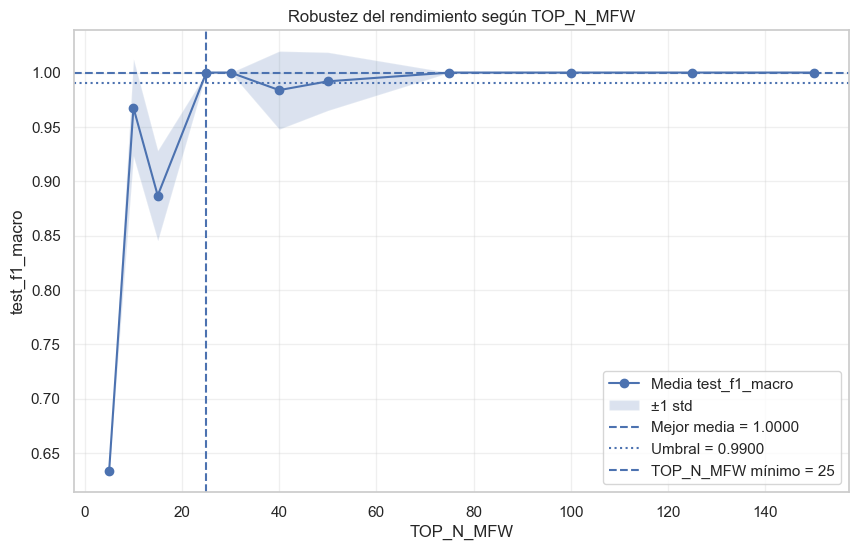

In [13]:
plot_mfw_performance_robustness(
    summary_by_topn=summary_by_topn,
    best_mean_score=best_mean_score,
    threshold_score=threshold_score,
    selected_top_n_mfw=selected_top_n_mfw,
)

## Tabla final de decisión

Esta tabla resume los resultados para cada valor de `TOP_N_MFW`, mostrando la media y la desviación estándar de `test_f1_macro`, así como una indicación de si ese valor de `TOP_N_MFW` cumple con el criterio de mantener un rendimiento dentro de la tolerancia establecida (`keeps_performance`).

También nos muestra el mejor modelo (`mode_best_model_name`) encontrado para cada valor de `TOP_N_MFW` y, de todos los modelos, cuál es el mejor modelo global (`selected=True`). Esto nos permite comparar fácilmente los resultados y tomar una decisión informada sobre el número óptimo de características de palabras funcionales a utilizar.

In [14]:
final_topn_decision_df = summary_by_topn.copy()
final_topn_decision_df["keeps_performance"] = final_topn_decision_df["mean_test_f1_macro"] >= threshold_score
final_topn_decision_df["selected"] = final_topn_decision_df["top_n_mfw"] == selected_top_n_mfw

final_topn_decision_df

,top_n_mfw,mean_test_f1_macro,std_test_f1_macro,min_test_f1_macro,max_test_f1_macro,mode_best_model_name,n_runs,keeps_performance,selected
0,5,0.633333,0.000000,0.633333,0.633333,svc_rbf,11,False,False
1,10,0.967677,0.044847,0.911111,1.000000,knn,11,False,False
2,15,0.886869,0.041520,0.822222,0.911111,knn,11,False,False
3,25,1.000000,0.000000,1.000000,1.000000,logreg,11,True,True
4,30,1.000000,0.000000,1.000000,1.000000,linear_svc,11,True,False
5,40,0.983838,0.035957,0.911111,1.000000,linear_svc,11,False,False
6,50,0.991919,0.026801,0.911111,1.000000,linear_svc,11,True,False
7,75,1.000000,0.000000,1.000000,1.000000,logreg,11,True,False
8,100,1.000000,0.000000,1.000000,1.000000,logreg,11,True,False
9,125,1.000000,0.000000,1.000000,1.000000,logreg,11,True,False


En este caso, y para una `SEED_TO_SPLIT` de `42`, el valor seleccionado de `TOP_N_MFW` es `25` y el mejor modelo global es el de regresión logística, lo que indica que se pueden usar solo 25 características de palabras funcionales sin sacrificar significativamente el rendimiento del modelo.

## Entrenar y exportar el mejor modelo

Una vez que sabemos qué modelo global es el mejor, lo entrenamos y lo exportamos a un archivo JSON para su uso posterior. Esto nos permitirá cargar el modelo fácilmente en el futuro sin tener que volver a entrenarlo, y también nos proporciona una forma de documentar los parámetros y el rendimiento del modelo seleccionado.

In [15]:
# Configuración final elegida por el experimento
TOP_N_MFW = 25
FINAL_MODEL_NAME = "logreg"

In [16]:
_, train_fw, test_fw, fw_cols = build_train_test_mfw(
    top_n=TOP_N_MFW,
    train_df=train_df,
    test_df=test_df,
    train_tokens_by_file=train_tokens_by_file,
    test_tokens_by_file=test_tokens_by_file,
)

In [17]:
# Separamos X e y para train y test usando
# las columnas de features seleccionadas
X_train_final = train_fw[fw_cols].copy()
X_test_final = test_fw[fw_cols].copy()
y_train = train_fw["author_norm"].copy()
y_test = test_fw["author_norm"].copy()

In [18]:
# Reentrenamos el mejor modelo con la configuración
# final y una semilla cualquiera (uso SEED_TO_SPLIT
# por consistencia con experimentos anteriores)
final_model = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED_TO_SPLIT)

# Usamos el mismo pipeline que en experimentos anteriores
best_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("clf", final_model),
    ]
)

# Entrenamos
best_pipe.fit(X_train_final, y_train)

# Obtenemos predicciones y evaluamos
y_pred = best_pipe.predict(X_test_final)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Test F1 Macro del modelo final con TOP_N_MFW={TOP_N_MFW}: {test_f1_macro:.4f}")

Test F1 Macro del modelo final con TOP_N_MFW=25: 1.0000


In [19]:
# Exportamos el pipeline (preprocesado + modelo final)
dump(best_pipe, ML_ARTIFACTS_PATH / "best_mfw_pipeline.joblib")

# Exportamos los conjuntos de entrenamiento y test
# utilizados en el experimento
train_fw.to_parquet(ML_ARTIFACTS_PATH / "train_mfw.parquet", index=False)
test_fw.to_parquet(ML_ARTIFACTS_PATH / "test_mfw.parquet", index=False)

# Generamos un diccionario con los metadatos del
# experimento para documentar el modelo exportado
metadata = {
    "model_name": "best_mfw_pipeline",
    "selected_model": FINAL_MODEL_NAME,
    "target": "author_norm",
    "top_n_mfw": TOP_N_MFW,
    "feature_columns": fw_cols,
    "n_features": len(train_fw.columns),
    "n_train_samples": len(X_train_final),
    "n_test_samples": len(X_test_final),
    "metrics": {
        "test_f1_macro": test_f1_macro,
    },
    "train_notebook": "04_mfw_robustness_experiment.ipynb",
    "split_seed": SEED_TO_SPLIT,
}

with open(ML_ARTIFACTS_PATH / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)